
Congrats....again! Based off the amazing work you did on the classification model, you've been promoted to chief of all data scientists in Hollywood, your a total celebrity....among data scientists :).  

Your boss, head of the studio, has now asked you to build a model to predict gross revenue in order to help them decide which movies to invest in.

Once again, you would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so...you leverage work you've done in the past to get the job done....you're a data scientist after all! 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.model_selection import train_test_split,RepeatedKFold,GridSearchCV
from sklearn import metrics
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor, export_graphviz 
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("../data/movie_metadata.csv")

movie_metadata.head()



,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


#2 Ensure all the variables are classified correctly and collapse factor variables as needed.

Combining steps 2 and 3 into one function

#3 Check for missing variables and correct as needed.

In [3]:
# Creating a function to clean the dataset and ordinally encode the target variable

def clean_data(df):
    df1  = df.drop(columns = ['director_name', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'actor_1_name', 'movie_title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link', 'actor_2_facebook_likes', 'aspect_ratio'])
    df1[["color", "genres", "language", "country", "content_rating"]] = OrdinalEncoder().fit_transform(df1[["color", "genres", "language", "country", "content_rating"]])
    df1 = df1.dropna()
    return df1

movies = clean_data(movie_metadata)


#4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

#5 Determine the variance of the target variable, is it normally distributed? If not, you may want to transform the target variable. Why might this be important?

In [4]:
target = movie_metadata.loc[movies.index, 'gross'] # Defining the target variable

y = np.log1p(target).dropna() # Defining the target variable in log scale
X = movies.loc[y.index] # Defining the independent variables

range = y.max() - y.min() # Calculating range of the gross variable
variance = y.var() # Calculating the variance of the gross variable

# Printing the results

print("Gross Revenue Range:", range) 
print("Gross Revenue Variance:", variance)

Gross Revenue Range: 15.355744158505136
Gross Revenue Variance: 4.6238641731581565


I converted the target variable to a log scale to eliminate the impact of outliers, creating a more normal distribution. Before doing so, the variance of the gross revenue variable was not normally distributed. This makes the model more accurate by accounting for the presence of outliers in the data.

#6 Split your data into test, tune, and train. (80/10/10)

In [5]:
# Splitting the data into test, tune, and train

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size  = 0.80, random_state = 42)
X_tune, X_test, y_tune, y_test = train_test_split(X_test, y_test,  train_size = 0.50,random_state = 77)

#7 Create the kfold object for cross validation.

In [6]:
kf = RepeatedKFold(n_splits = 10, n_repeats = 2, random_state = 40)  # Creating the kfold object with 10 splits and 2 repeats

#8 Create the scoring metric (several measures) you will use to evaluate your model and choose a hyperparamater to optimize.

In [7]:
param = {"min_samples_leaf": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]} # Using min_samples_leaf as the hyperparameter with a range from 1 to 15.

scoring = ['neg_mean_squared_error','r2','neg_mean_absolute_error'] # Creating the scoring metrics


#9 Build the regression tree object. 

In [8]:
reg_tree = DecisionTreeRegressor(random_state = 121) # Creating the regression tree object

#10 Fit the model to the training data.

In [9]:
grid_search = GridSearchCV(reg_tree, param, scoring = scoring, n_jobs = -1, cv = kf, refit = 'neg_mean_squared_error') # Creating the grid_search object

model = grid_search.fit(X_train, y_train) # Fitting the model to the training data

#11 Explore the results of the model. Print the output of the grid search. What is the best parameter and score?

In [10]:
print(pd.DataFrame(model.cv_results_)) # Printing the output of the grid search
print("Best Parameter:", model.best_estimator_) # Printing the best parameter
print("Best Score:", model.best_score_)  # Printing the best score

    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        0.051890      0.008534         0.004261        0.002394   
1        0.039561      0.004305         0.002945        0.000202   
2        0.034560      0.002238         0.002785        0.000152   
3        0.031666      0.000601         0.002828        0.000179   
4        0.030511      0.001904         0.003155        0.001428   
5        0.032885      0.006541         0.003290        0.001211   
6        0.028717      0.003953         0.003306        0.000356   
7        0.029901      0.005137         0.003398        0.000744   
8        0.026999      0.001937         0.003442        0.000910   
9        0.025991      0.000905         0.003172        0.000503   
10       0.029429      0.008475         0.003973        0.001557   
11       0.028166      0.007110         0.003693        0.002000   
12       0.025414      0.003370         0.003543        0.001705   
13       0.027331      0.008036         0.003049

#12 Which variables appear to be contributing the most (variable importance) 

In [11]:
best_param = model.best_estimator_  # Extracting the best estimator from grid search

variable_importance = pd.DataFrame(best_param.feature_importances_, index = X.columns, columns=['importance']).sort_values('importance', ascending = False)
print(variable_importance)

                           importance
num_voted_users              0.501752
budget                       0.241159
num_user_for_reviews         0.056190
title_year                   0.054239
country                      0.052376
content_rating               0.049307
cast_total_facebook_likes    0.009955
imdb_score                   0.009704
language                     0.007811
num_critic_for_reviews       0.007508
movie_facebook_likes         0.004317
genres                       0.004038
duration                     0.001555
facenumber_in_poster         0.000088
color                        0.000000


num_voted_users and budget appear to be contributing the most to the prediction of gross revenue.

#13 Create a model object using the best model hyperparameter value from the trained regression tree. 

In [12]:
new_model = best_param.fit(X_train, y_train)  # Creating a model using the best hyperparameter from the trained regression tree

#14 Using the best model predict on the tune data and print out the results.

In [13]:
tune_pred = new_model.predict(X_tune)  # Using the new model to predict the tune data
print(tune_pred)

[16.71098669 15.03325089 17.94952265 16.34933659 16.18589536 14.41086727
 17.08478911 13.96776161 19.7313155  17.73951403 17.0748651  17.39764952
 16.91822775 17.7133778  18.82305605 13.63228938 12.68710625 11.76713447
 17.77659299 14.41061449 12.68710625 16.69234644 18.32185239 17.94952265
 17.39764952 17.7133778  17.79286777 12.10439843 17.97597382 16.91130774
 16.87813382 17.24152123 16.91822775 16.61109166 17.79286777 16.07792265
 17.51141935 17.51141935 18.70828098 17.43453083 17.50662366 18.17586584
 14.61287714 16.61109166 17.97610603 19.7313155  19.31003778 15.88556637
 16.02659182 17.3449058  17.13866921 17.13866921 18.03260809 16.93259922
 18.17586584 18.65361762 17.09806957 13.72360115 16.91822775 14.49208468
 17.97610603 16.61109166 17.98339029 16.91822775 13.86259525 17.81523331
 17.81847947 15.40528529 17.2449206  17.24152123 15.85499193 18.78863886
 18.49082565 16.18589536 17.94952265 19.10948646 18.40924581 17.79623861
 18.58510441 13.96776161 18.25759739 13.96776161 19

#15 How does the model perform on the tune data as compared to the training data?

In [14]:
train_pred = new_model.predict(X_train)  # Predicting the training data

# Calculating the scoring metrics for the training data

train_mse_neg = -mean_squared_error(y_train, train_pred)
train_r2 = r2_score(y_train, train_pred)
train_mae_neg = -mean_absolute_error(y_train, train_pred)

# Calculating the scoring metrics for the tuning data

tune_mse_neg = -mean_squared_error(y_tune, tune_pred)
tune_r2 = r2_score(y_tune, tune_pred)
tune_mae_neg = -mean_absolute_error(y_tune, tune_pred)

# Turning the results into dataframes

train_data = pd.DataFrame({'Train -MSE': [train_mse_neg], 'Train R2': [train_r2], 'Train -MAE': [train_mae_neg]})
tune_data = pd.DataFrame({'Tune -MSE': [tune_mse_neg], 'Tune R2': [tune_r2], 'Tune -MAE': [tune_mae_neg]})

# Printing the dataframes

print(train_data)
print(tune_data)

   Train -MSE  Train R2  Train -MAE
0   -1.352247  0.699402   -0.781792
   Tune -MSE   Tune R2  Tune -MAE
0  -2.224182  0.574219  -0.973805


The new model performs better on the training data than the tuning data, shown by the larger R2 score. The training data also has a negative mean squared error and negative mean absolute error closer to 0.

#16 What five movies are predicted to have the lowest gross revenue from the tune set? 

In [15]:
tune_pred_df = pd.DataFrame(tune_pred, index = X_tune.index, columns=['gross_pred']) # Turning tune_pred into a dataframe

tune_lowest = tune_pred_df.sort_values(by = 'gross_pred', ascending = True) # Sorting the gross predictions in ascending order

tune_lowest_5 = tune_lowest.head(5) # Selecting the five lowest gross revenues

worst_movies = movie_metadata.loc[tune_lowest_5.index, 'movie_title'] # Getting the movie titles of the 5 worst movies

print(worst_movies) # Printing the lowest predicted gross revenue movies


3959          Inescapable 
4294    The Virginity Hit 
4386                  Yes 
4830      Pieces of April 
4684         Donkey Punch 
Name: movie_title, dtype: object


#17 As a data scientist you are always looking to improve your results. What are some ideas you have to improve the model? Have you ask...WHAT IF?!

Possible ways to improve the model include one-hot encoding the categorical variables instead of ordinally encoding them, as well as trying a different hyperparameter to test, such as "min_weight_fraction_leaf."

#18 Experiment using your what if ideas (two is fine). Did the model improve? If so, how much? If not, what did you learn? (You don't need to include all the "what if" code just speak to what you tried and what you learned).

In [16]:
# Creating a model with one-hot encoded variables and using "min_weight_fraction_leaf" as the hyperparameter.

# Adjusting the clean data function to one-hot encode the categorical variables

def clean_data_1(df):
    df1  = df.drop(columns = ['director_name', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name', 'actor_1_facebook_likes', 'gross', 'actor_1_name', 'movie_title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link', 'actor_2_facebook_likes', 'aspect_ratio'])
    df1 = pd.get_dummies(df1, columns = ["color", "genres", "language", "country", "content_rating"], drop_first = True)
    df1 = df1.dropna()
    return df1

fraction_model = clean_data_1(movie_metadata)

target = movie_metadata.loc[fraction_model.index, 'gross'] # Defining the target variable

y = np.log1p(target).dropna() # Defining the target variable in log scale
X = fraction_model.loc[y.index] # Defining the independent variables

# Splitting the data into test, tune, and train

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size  = 0.80, random_state = 42)
X_tune, X_test, y_tune, y_test = train_test_split(X_test, y_test,  train_size = 0.50,random_state = 77)

kf = RepeatedKFold(n_splits = 10, n_repeats = 2, random_state = 40)  # Creating the kfold object with 10 splits and 2 repeats

param_new = {"min_weight_fraction_leaf":[0, 0.1, 0.2, 0.3, 0.4, 0.5]} # Using "min_weight_fraction_leaf" as the new hyperparameter

scoring = ['neg_mean_squared_error','r2','neg_mean_absolute_error'] # Creating the scoring metrics

reg_tree = DecisionTreeRegressor(random_state = 121) # Creating the regression tree object

grid_search = GridSearchCV(reg_tree, param_new, scoring = scoring, n_jobs = -1, cv = kf, refit = 'neg_mean_squared_error') # Creating the grid_search object

new_model_1 = grid_search.fit(X_train, y_train) # Fitting the model to the training data

# Calculating the scoring metrics for the training data

train_pred_1 = new_model_1.best_estimator_.predict(X_train)

train_mse_neg_1 = -mean_squared_error(y_train, train_pred_1)
train_r2_1 = r2_score(y_train, train_pred_1)
train_mae_neg_1 = -mean_absolute_error(y_train, train_pred_1)

print("Train -MSE:", train_mse_neg_1)
print("Train -R2:", train_r2_1)
print("Train -MAE:", train_mae_neg_1)



Train -MSE: -2.4942906569481536
Train -R2: 0.4968895583144878
Train -MAE: -1.107038503543979


My original model performed better because the training set had an MSE roughly 1.14 closer to 0, an R2 score approximately 0.2 higher, and an MAE roughly 0.32 closer to 0 than the new model.

#19 Use the best model to predict on the test data and print out the evaluation results.

In [18]:
new_model = best_param.fit(X_train, y_train)  # Defining the best model

test_pred_1 = new_model.predict(X_test) # Using the best model to predict the test data

# Calculating scoring metrics for the test data

test_mse_neg_1 = -mean_squared_error(y_test, test_pred_1)
test_r2_1 = r2_score(y_test, test_pred_1)
test_mae_neg_1 = -mean_absolute_error(y_test, test_pred_1)

print("Test -MSE:", test_mse_neg_1)
print("Test R2:", test_r2_1)
print("Test -MAE:", test_mae_neg_1)



Test -MSE: -2.2813316439276505
Test R2: 0.524878819845155
Test -MAE: -1.0069390131866103


#20 Does the model perform well on the test data when compared to the training and tune data? Why or why not? 

The model performs worse on the test data than on the training and tune data, as shown by the smaller R2 score and larger MSE and MAE. This could be due to overfitting of the training data.

#21 Where are the errors occurring in your predictions? Are they systematic or random? In either case, what are the implications of this?

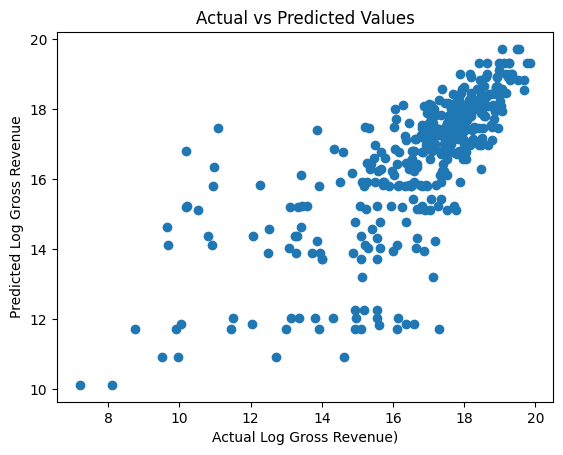

In [23]:
plt.scatter(y_test, test_pred_1)
plt.xlabel("Actual Log Gross Revenue)")
plt.ylabel("Predicted Log Gross Revenue")
plt.title("Actual vs Predicted Values")
plt.show()

Based on the scatterplot comparing actual vs predicted values, the majority of errors occur between the log gross revenue values of 10-16, which is a systematic error. Values below this and above this range are more accurately predicted, as shown by the diagonal clustering. This means that the model better predicts lower and higher grossing movies, but struggles to predict the the mid-range grossing movies.

#22 Summarize what you learned along the way and make recommendations on how this could be used moving forward, being careful not to over promise.

Throughout this assignment, I learned how ordinally encoding categorical variables is often better for regression trees than one-hot encoding. I also learned how to analyze new scoring metrics such as negative MAE and MSE, as well as R2. I would recommend using an ordinally-encoded model with a large emphasis on budget and num_voted_users to predict gross revenue in the future.